In [1]:
%load_ext autoreload
%autoreload 2
import sys
import os
import time
import pickle
import json
import csv

# notebooks/ から見た src のパスを追加
sys.path.append(os.path.abspath("../src"))

# 自作パッケージを import
from sim_utils import *
import pymdp



In [2]:
import sys
import os
import time

Ts = time.time()

# notebooks/ から見た src のパスを追加
sys.path.append(os.path.abspath("../src"))

# sys.path.append(os.path.abspath("../yglab/pymdp"))

# 自作パッケージを import
from sim_utils import *
import pymdp

# すべてのパラメータ設定
config_json = {}

# ロボットモデルの設定
# モデル・データ読み込み
dof = 3
model = get_simple_arm(dof=dof)  # 自分のURDFを読み込むなら buildModelFromUrdf
data = model.createData()
# 可動域の設定
limits = same_limits(model.nq)
velocity_scale = 5.0
effort_scale = 10.0

model.velocityLimit = np.full(dof, np.pi * velocity_scale)
model.effortLimit = np.full(dof, np.pi * effort_scale)
print(f"Angle Limits: {model.lowerPositionLimit}, {model.upperPositionLimit}")
print(f"Velocity Limits: -{model.velocityLimit}, {model.velocityLimit}")
print(f"Effort Limits: -{model.effortLimit}, {model.effortLimit}")

# 始点と終点の設定
# エンドエフェクタのframe名とid
frame_name = "ee_link"
frame_id = model.getFrameId(frame_name)
# 目標位置と姿勢の計算（SE3）
theta = np.pi/4
Rs = pin.utils.rotate("y", -3*theta)
start_placement = pin.SE3(Rs, np.array([-2, 0, 0]))
Re = pin.utils.rotate("y", 3*theta)
end_placement = pin.SE3(Re, np.array([2, 0, 0]))

start = ik_se3_solver(model, data, frame_id, start_placement)
end = ik_se3_solver(model, data, frame_id, end_placement)

robot_config = {"dof": dof, "limits": limits.tolist(), "velocity_scale": velocity_scale, "effort_scale": effort_scale,
                "start": start.tolist(), "end": end.tolist()}
config_json["robot_config"] = robot_config

# エージェントの準備
bin_M = 30
eps = 1.0e-3 # 1.0e-3が先行研究
var_a = 1/bin_M 
var_b = 1/bin_M
num_iter = 16
num_history = 16

num_obs = [bin_M for _ in range(dof*3)]
agent = RobotPerceptor(
    num_obs = num_obs,
    # num_obs=[10,10,10, 10,10,10, 10,10,10],
    # num_obs=[15, 15, 15, 15, 15, 15, 15, 15, 15],
    # num_obs=[bin_M, bin_M, bin_M, bin_M, bin_M, bin_M, bin_M, bin_M, bin_M],
    # noise=0.1, # 観測ノイズ
    eps=eps,
    Avars=[var_a, var_a, var_a],
    Bvars=[var_b, var_b, var_b],
    num_iter=num_iter,
    num_history=num_history
)
# plot_A_all(agent.A)
# plot_B_all(agent.B)
agent_config = {"dof": dof, "bin_M": bin_M, "eps": eps, "var_a": var_a, "var_b": var_b,
                "num_iter": num_iter, "num_history": num_history, "num_obs": num_obs}
config_json["agent_config"] = agent_config

# オプティマイザの設定
fps = 30 # 本番は30
sec = 5 # 本番は5
time_steps = int(fps * sec) # 本番は150
dt = float(1/fps)
print(f"time_steps: {time_steps}, dt: {dt}")

# 最適化のパラメータ
num_knots = 9
# n_particles = 500
# iters = 100
compensate_grav = False

opt_config = {"fps": fps, "sec": sec, "time_steps": time_steps, "dt": dt, "num_knots": num_knots, "compensate_grav": compensate_grav}
config_json["opt_config"] = opt_config

Te = time.time()
print(f"param set in ({Te-Ts:.2f}sec)")
Ts = time.time()

# Optimizerの初期化
opt = Optimizer(model, agent, time_steps, dt, start, end, limits, num_knots)

Te = time.time()
print(f"optimizer initialized in {Te-Ts:.2f}sec")
# 事前分布となる動きの生成
# トルク最小化によって生成
beliefs_result = opt.scipy_optimize(
    torque_change=1.0, 
    compensate_grav=False,
    maxfun= 1e10,
    maxiter=1e10,
    ftol=1e-8,
    initial_seed=1)

# # 等速運動による生成
# best_particle, best_qs = opt.linear_base_particle()

plot_robot_motion(beliefs_result)
# 事前分布をoptimizerに設定
opt.set_const_beliefs(beliefs_result)
# BASE_SAVE_DIR = opt.setup_save_directory()
beliefs_result.info()

URDFファイルを ./robots/simple_arm_dof3.urdf に保存しました。自由度: 3
URDFファイルを ./robots/simple_arm_dof3.urdf に保存しました。自由度: 3
Angle Limits: [-3.14 -3.14 -3.14], [3.14 3.14 3.14]
Velocity Limits: -[15.70796327 15.70796327 15.70796327], [15.70796327 15.70796327 15.70796327]
Effort Limits: -[31.41592654 31.41592654 31.41592654], [31.41592654 31.41592654 31.41592654]
収束しました！ iteration: 23
収束しました！ iteration: 23


INFO:2025-12-20 03:54:21,322:jax._src.xla_bridge:752: Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory
2025-12-20 03:54:21,322 - jax._src.xla_bridge - INFO - Unable to initialize backend 'tpu': INTERNAL: Failed to open libtpu.so: libtpu.so: cannot open shared object file: No such file or directory


time_steps: 150, dt: 0.03333333333333333
param set in (7.26sec)
optimizer initialized in 0.00sec
initial_particle: [-0.52136612  1.38433962 -3.14087402 -1.24198108 -2.2194982  -2.56141215
 -1.97128523 -0.97037057 -0.64862909  0.24389273 -0.50771584  1.16376844
 -1.85698128  2.37578192 -2.96951133  1.07107896 -0.51958925  0.36875907
 -2.2595155  -1.89688429  1.88963386]


2025-12-20 03:54:53,992 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.HTMLWriter'>



Optimization Status: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
Final Cost: 815.6649
Now preparing HTML display...


🚀 OPTIMIZATION RESULT PREVIEW (Scipy_L-BFGS-B)
## 1. 最終結果とステータス (Quick Look)
   - 最小コスト (Best Cost): 815.664880
   - 収束ステータス: True
   - 終了メッセージ: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH
   - 最終メトリクス: { 'jerk': 130.7802, 'energy': 65.4359, 'torque_change': 815.6649 }
   - 最適軌道 (qs) サイズ: (150, 3)

## 2. 最適化設定
   - コスト関数 (Cost Func): N/A
   - オプティマイザ: Scipy_L-BFGS-B
   - プロセス設定 (Params): { 'num_knots': 9, 'maxiter': 10000000000.0000, 'ftol': 0.0000, 'random_seed': 1 }

## 3. 計算量と履歴
   - 反復回数 (nit): 783
   - 関数評価回数 (nfev): 18942
   - コスト履歴: なし (0 points)

## 4. ロボットと軌道パラメータ (再現用)
   - 自由度 (DOF): 3
   - モデルキー: simple_arm_dof3
   - 総時間: 5.00 s (150 steps)
   - 重力補償: False
   - 初期/目標姿勢: Start: Shape (3,), [-0.32787015830683996, -1.4849040314826436, -0.54342001952259], End: Shape (3,), [0.32787015830683996, 1.4849040314826436, 0.54342001952259]

## 5. Perception Agentパラメータ
   - Agent設定: 無効
   - Agent Params: {}


"==================================================\n🚀 OPTIMIZATION RESULT PREVIEW (Scipy_L-BFGS-B)\n==================================================\n## 1. 最終結果とステータス (Quick Look)\n   - 最小コスト (Best Cost): 815.664880\n   - 収束ステータス: True\n   - 終了メッセージ: CONVERGENCE: RELATIVE REDUCTION OF F <= FACTR*EPSMCH\n   - 最終メトリクス: { 'jerk': 130.7802, 'energy': 65.4359, 'torque_change': 815.6649 }\n   - 最適軌道 (qs) サイズ: (150, 3)\n\n## 2. 最適化設定\n   - コスト関数 (Cost Func): N/A\n   - オプティマイザ: Scipy_L-BFGS-B\n   - プロセス設定 (Params): { 'num_knots': 9, 'maxiter': 10000000000.0000, 'ftol': 0.0000, 'random_seed': 1 }\n\n## 3. 計算量と履歴\n   - 反復回数 (nit): 783\n   - 関数評価回数 (nfev): 18942\n   - コスト履歴: なし (0 points)\n\n## 4. ロボットと軌道パラメータ (再現用)\n   - 自由度 (DOF): 3\n   - モデルキー: simple_arm_dof3\n   - 総時間: 5.00 s (150 steps)\n   - 重力補償: False\n   - 初期/目標姿勢: Start: Shape (3,), [-0.32787015830683996, -1.4849040314826436, -0.54342001952259], End: Shape (3,), [0.32787015830683996, 1.4849040314826436, 0.54342001952259]\n\n## 5. Pe

In [3]:
# ランダム動作のシミュレーションと評価
import seaborn as sns
import pandas as pd
from tqdm.notebook import tqdm
import time


# いろいろ保存するための準備
import time
import os
import json

BASE_SAVE_DIR="/home/rikut/py_venvs/my_sim_project/results"
# --- 実行メタデータと統合 ---
timestamp = time.strftime("%Y%m%d_%H%M%S")
unique_id = f"sim_dof{dof}_{timestamp}"
# sim_dirに今回の結果を格納していく
sim_dir = os.path.join(BASE_SAVE_DIR, unique_id)
os.makedirs(sim_dir, exist_ok=True)


energies = []
jerks = []
torque_changes = []
vfes = []
klds = []
bss = []
uns = []
qss = []

num_knots = opt.num_knots

iter = 491 # 先行研究では491?(varの間隔が0.001)

varmin = 0.01 * (2*np.pi) # 先刻研究通りなら0.01(ただし制御点は0~1の値域であったので、ここでは関節角度にスケールするべきか)
varmax = 0.5 * (2*np.pi) # 先刻研究通りなら0.5(ただし制御点は0~1の値域であったので、ここでは関節角度にスケールするべきか)

n_divisions = iter
var_list = np.linspace(varmin, varmax, n_divisions, endpoint=True)

landscape_config = {"iter": iter, "varmin": varmin, "varmax": varmax, "var_list": var_list.tolist()}
config_json["landscape_config"] = landscape_config

# 基準とする動き
base_particle = opt.const_beliefs_result.best_particle
particle_hist = []

# optimizer
model = opt.model
time_steps = opt.timesteps
start = opt.start
end = opt.end
data = opt.data
dt = opt.dt
compensate_grav = False # Falseで重力考慮、Trueで無重力
env = opt.env
const_beliefs = opt.const_beliefs

pbar = tqdm(range(iter), desc="シミュレーション中", position=1)
for i in pbar:
    start_time = time.time()

    # ランダムな動きを生成し、環境に設定
    # qs = random_qs_spline(model, time_steps, start, end, seed=i, num_knots=num_knots)
    # opt.env.computeAllobs(qs, dt)

    # もととなる動きにノイズを加える形で生成するバージョン
    var = var_list[i]
    (qs ,grads), particle= random_qs_from_base(model, time_steps, 
                                   start, end, 
                                   base_particle=base_particle, 
                                   var=var, limits=limits, seed=i, 
                                   type="B-spline", 
                                   grad1=True, grad2=True, grad3=True,
                                   particle_return=True)
    # opt.env.computeAllobs(qs, dt)

    particle_hist.append(particle)
    dqs, ddqs, dddqs = grads

    # 速度 (1階微分) を補正: dqs / dt
    dqs = dqs / dt
    # 加速度 (2階微分) を補正: ddqs / dt^2
    ddqs = ddqs / (dt ** 2)
    # ジャーク (3階微分) を補正: dddqs / dt^3
    dddqs = dddqs / (dt ** 3)

    # 動きの消費エネルギーを計算
    energy = compute_total_energy(model, data, qs, dqs, ddqs, dt, compensate_grav=compensate_grav)
    energies.append(energy)
    # ジャーク
    jerk = compute_total_jerk(dddqs, dt)
    jerks.append(jerk)
    # トルク変化
    torque_change = compute_total_torque_change(model, data, qs, dqs, ddqs, dt, compensate_grav=compensate_grav)
    torque_changes.append(torque_change)

    # 観測させて各指標の合計をストック
    opt.agent.reset()
    # opt.agent.run_perception(timesteps=time_steps, env=opt.env, const_beliefs=opt.const_beliefs, num_history=num_history)
    # opt.agent.bayse_estimate(timesteps=time_steps, env=opt.env, const_beliefs=opt.const_beliefs, num_history=num_history)
    vfe, kld, bs, un = compute_total_vfe(agent, env, qs, dt, const_beliefs)
        
    # この段階では時系列準のvfe, kld, bs, unをスタックしていく
    vfes.append(vfe)
    klds.append(kld)
    bss.append(bs)
    uns.append(un)
    qss.append(qs)

    elapsed_time = time.time() - start_time
    # ❗ pbar.set_description_str()を使って、進捗バーの表示内容を更新 ❗
    # 処理のステップと最新のPerception時間を表示します。
    new_desc = f"Sim: {i+1}/{iter} | Percep. time: {elapsed_time:.2f}s"
    pbar.set_description_str(new_desc)

pbar.close()


シミュレーション中:   0%|          | 0/491 [00:00<?, ?it/s]

In [4]:
# いろいろ保存する
import time
import os
import json
import pickle

# データ分析など
import pandas as pd
import numpy as np

# 保存するフォルダは引き続き同じ
sim_dir = sim_dir
os.makedirs(sim_dir, exist_ok=True)
# simulationの設定を保存するフォルダ
config_dir = os.path.join(sim_dir, "config")
os.makedirs(config_dir, exist_ok=True)
# simulationの結果を保存するフォルダ
landscape_dir = os.path.join(sim_dir, "landscape")
os.makedirs(landscape_dir, exist_ok=True)

# 設定を保存
# config_jsonを保存
file_name = "config.json"
config_json_path = os.path.join(config_dir, file_name)
with open(config_json_path, 'w') as f:
    json.dump(config_json, f, indent=4)
print(f"Config JSON saved to: {config_json_path}")

# robot modelを保存
robot = opt.model
file_name = "robot.pkl"
robot_path = os.path.join(config_dir, file_name)
with open(robot_path, 'wb') as f:
    pickle.dump(robot, f)
print(f"Robot model saved to: {robot_path}")

# agentを保存
agent = opt.agent
file_name = "agent.pkl"
agent_path = os.path.join(config_dir, file_name)
with open(agent_path, 'wb') as f:
    pickle.dump(agent, f)
print(f"Agent saved to: {agent_path}")

# const_beliefsを保存
file_name = "const_beliefs_result.pkl"
const_beliefs_result = opt.const_beliefs_result
const_beliefs_result.save(config_dir, file_name)
# print(f"Const beliefs saved to: {const_beliefs_path}")


# 1. オブジェクトの状態（__dict__）を取得
optimizer_state = opt.__dict__
# 2. 状態辞書を別のファイル名で保存
# (例: "optimizer_state.pkl"として保存)
state_file_name = "optimizer_state.pkl"
state_optimizer_path = os.path.join(config_dir, state_file_name)
with open(state_optimizer_path, 'wb') as f:
    pickle.dump(optimizer_state, f)
print(f"Optimizer state (data) saved to: {state_optimizer_path}")

try:
    # optimizerそのものを保存
    used_optimizer = opt
    file_name = "used_optimizer.pkl"
    optimizer_path = os.path.join(config_dir, file_name)
    with open(optimizer_path, 'wb') as f:
        pickle.dump(used_optimizer, f)
    print(f"Optimizer saved to: {optimizer_path}")
except:
    print(f"Standard pickle failed for {file_name}, using state data as backup.")
    

# 生成したデータを保存
raw_data = {'energy': energies, 'jerk': jerks, 'torque_change': torque_changes, 'vfe': vfes, 'kld': klds, 'bs': bss, 'un': uns, 'qs': qss}
file_name = "raw_data.pkl"
raw_data_path = os.path.join(landscape_dir, file_name)
with open(raw_data_path, 'wb') as f:
    pickle.dump(raw_data, f)
print(f"Raw data saved to: {raw_data_path}")


Config JSON saved to: /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/config/config.json
Robot model saved to: /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/config/robot.pkl
Agent saved to: /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/config/agent.pkl
Success: Optimization result saved to const_beliefs_result.pkl and summary to const_beliefs_result.txt
Optimizer state (data) saved to: /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/config/optimizer_state.pkl
Optimizer saved to: /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/config/used_optimizer.pkl
Raw data saved to: /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/landscape/raw_data.pkl


Loaded: raw_data.pkl
データフレームを保存しました: /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/landscape/simulation_results.csv
--- 統合されたターゲット値（中央値と平均値）---
| Metric   |   P5_Low |   P50_Mid_Median |   P95_High |   Mean_P5_P95 |
|:---------|---------:|-----------------:|-----------:|--------------:|
| vfe      | 217.2569 |         445.3164 |   649.2925 |      433.2747 |
| energy   |  44.7434 |         757.7586 |  3763.3212 |     1904.0323 |
| ig       |  69.2550 |         144.4127 |   170.0028 |      119.6289 |
✅ 平均値ターゲットを含むバイオリンプロットを保存しました: /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/landscape/robust_targets_violinplots_with_mean.png


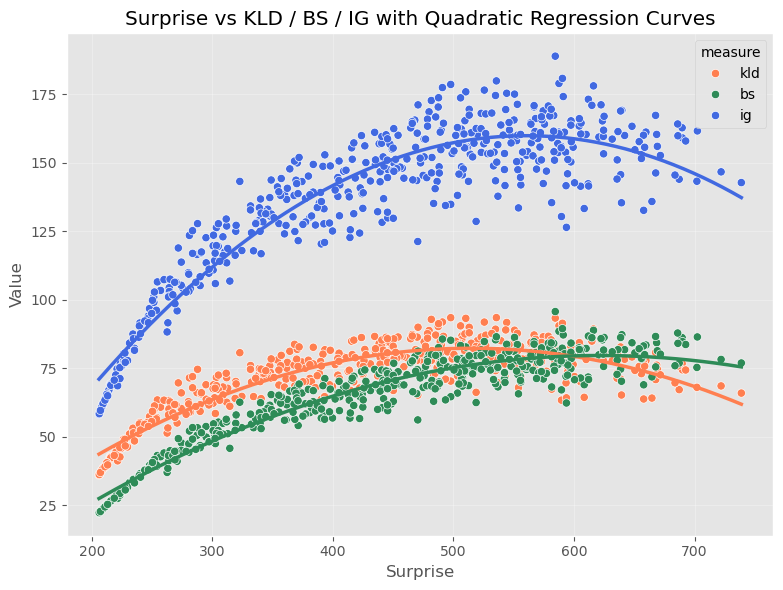

/tmp/ipykernel_1190411/2802744225.py:335: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


✅ 3次元プロットを保存しました: /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/landscape/ig_vs_surprise_energy_3d_viridis.png
✅ 2次元俯瞰図（奥行き強調）を保存しました: /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/landscape/ig_vs_surprise_energy_2d_heatmap_depth.png


/tmp/ipykernel_1190411/2802744225.py:431: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap(cmap_name)


✅ IG vs Energy (Surprise強調) プロットを保存しました: /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/landscape/ig_vs_energy_depth_by_surprise.png


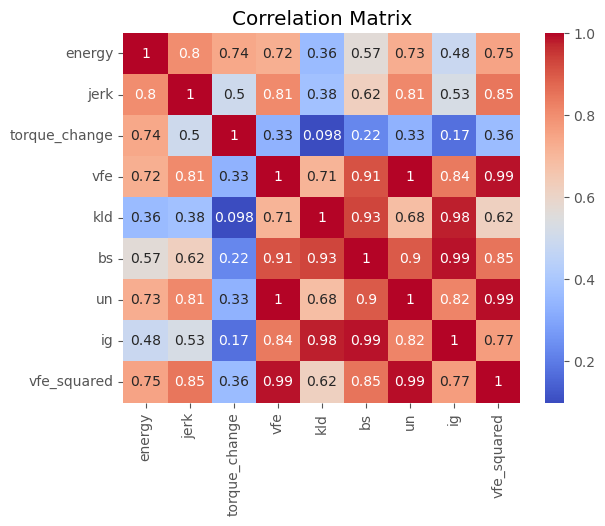

In [5]:
# データ分析と可視化
# データ分析など
import os
import json
import pickle
import pandas as pd
import numpy as np

# 保存したデータをロード
file_name = "raw_data.pkl"
raw_data_path = os.path.join(landscape_dir, file_name)
try:
    with open(raw_data_path, 'rb') as f:
        raw_data = pickle.load(f)
    print(f"Loaded: {file_name}")
except Exception as e:
    print(f"Failed to load {file_name}: {e}")

file_name = "used_optimizer.pkl"
optimizer_path = os.path.join(config_dir, file_name)
try:
    with open(optimizer_path, 'rb') as f:
        opt = pickle.load(f)
except Exception as e:
    print(f"Failed to load {file_name}: {e}")



energies = raw_data["energy"]
jerks = raw_data["jerk"]
torque_changes = raw_data["torque_change"]
vfes = raw_data["vfe"]
klds = raw_data["kld"]
bss = raw_data["bs"]
uns = raw_data["un"]

# データフレームの準備
# ylabels = ['vfe', 'kld', 'bs', 'un', ]
df = pd.DataFrame({'energy': energies, 'jerk': jerks, 'torque_change': torque_changes, 'vfe': vfes, 'kld': klds, 'bs': bss, 'un': uns})
# df['surprise'] = df['vfe'] - df['kld']これは間違い vfeが収束後なのでsurpriseそのもの
df['ig'] = df["kld"] + df["bs"]
ylabels = list(df.columns)

list_columns = ['vfe', 'kld', 'bs', 'un', 'ig']
for col in list_columns:
    if col in df.columns and not df[col].empty:
        # 最初の要素がリスト、NumPy配列、またはJAX配列であることを確認
        first_element = df[col].iloc[0]

        # リストまたはNumPy配列の場合
        if isinstance(first_element, (np.ndarray, list)):
            try:
                # 1. 各セル内の配列/リストに対して np.sum() を適用し、総和（スカラー値）を計算
                # 2. 結果のSeriesのdtypeを np.float64 に設定し直す (applyの戻りは通常objectになるため)
                df[col] = df[col].apply(lambda x: np.sum(x)).astype(np.float64)
                
            except Exception as e:
                print(f"Warning: Failed to sum elements in column '{col}': {e}")
        
        # JAX配列の場合も同様に np.sum() で処理可能
        elif 'jax' in str(type(first_element)):
            try:
                # JAX ArrayImplも np.sum() で総和を計算可能
                df[col] = df[col].apply(lambda x: np.sum(x)).astype(np.float64)
            except Exception as e:
                print(f"Warning: Failed to sum JAX elements in column '{col}': {e}")

for col in df.columns:
    if col=="qs":
        break
    # 現在の列のデータ型を確認し、もしJAXの配列型（またはオブジェクト型でNumPyに変換可能なもの）であれば変換
    if isinstance(df[col].iloc[0], (np.ndarray, list)):
        # リストやNumPy配列の場合はそのままastypeで型変換
        df[col] = df[col].astype(np.float64)
    elif 'jax' in str(type(df[col].iloc[0])):
        # JAXの型（ArrayImplなど）の場合は、まずNumPy配列に変換してからpandasのシリーズに戻す
        df[col] = np.array(df[col].tolist(), dtype=np.float64)
    else:
        # 既存の数値データ型はそのまま維持
        try:
            df[col] = df[col].astype(np.float64)
        except:
            # 数値でない列（もしあれば）はそのまま
            pass

df_path = os.path.join(landscape_dir, "simulation_results.csv")
# CSV形式で保存 (汎用性)
df.to_csv(os.path.join(landscape_dir, "simulation_results.csv"), index=False)
print(f"データフレームを保存しました: {df_path}")



# 二次回帰
import statsmodels.api as sm
from statsmodels.formula.api import ols

# ----------------------------------------------------
# 1. 二乗項の作成
# ----------------------------------------------------
df['vfe_squared'] = df['vfe'] ** 2

# 予測用のデータフレーム（滑らかな曲線を描くために細かくデータ点を生成）
vfe_range = np.linspace(df['vfe'].min(), df['vfe'].max(), 200)
pred_df = pd.DataFrame({'vfe': vfe_range, 'vfe_squared': vfe_range ** 2})

# ----------------------------------------------------
# 2. 各目的変数に対する回帰分析の実行と予測値の計算
# ----------------------------------------------------
target_vars = ["kld", "bs", "ig"]
formula = 'Y ~ vfe + vfe_squared'

# 予測値を格納するための新しいDataFrame
predicted_curves = pred_df[['vfe']].copy()

for var in target_vars:
    # 目的変数を 'Y' に一時的にコピーしてモデルを適合
    df_temp = df.rename(columns={var: 'Y'})
    
    # OLSモデルの構築と適合 (Y ~ vfe + vfe_squared)
    reg_model = ols(formula, data=df_temp).fit()
    
    # 予測値の計算
    predicted_curves[var] = reg_model.predict(pred_df)

# ----------------------------------------------------
# 3. 予測値を seaborn 用に melt で縦長データに変換
# ----------------------------------------------------
# 予測値を melt して元のdf_meltと同じ形式にする
predicted_curves_melt = predicted_curves.melt(
    id_vars="vfe", 
    value_vars=target_vars, 
    var_name="measure", 
    value_name="predicted_value"
)


import seaborn as sns
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D

# 可視化関連
# -----------------------------

# 可視化する変数
variables = ['vfe', 'energy', 'ig']

# 1. すべてのターゲット値を計算し、辞書に統合
all_targets = {}

for var in variables:
    # パーセンタイル値の計算
    p5 = df[var].quantile(0.05)
    p50 = df[var].quantile(0.50)
    p95 = df[var].quantile(0.95)
    
    # P5とP95の算術平均値を計算
    mean_p5_p95 = (p5 + p95) / 2
    
    # 結果を格納
    all_targets[var] = {
        'P5_Low': p5,
        'P50_Mid_Median': p50,
        'P95_High': p95,
        'Mean_P5_P95': mean_p5_p95
    }

print("--- 統合されたターゲット値（中央値と平均値）---")
targets_data = []
for var, values in all_targets.items():
    targets_data.append({
        'Metric': var,
        'P5_Low': values['P5_Low'],
        'P50_Mid_Median': values['P50_Mid_Median'],
        'P95_High': values['P95_High'],
        'Mean_P5_P95': values['Mean_P5_P95']
    })
targets_df = pd.DataFrame(targets_data)
print(targets_df.to_markdown(index=False, floatfmt=".4f"))

# 1. 可視化設定
colors = ['#FF9999', '#99FF99', '#9999FF'] # VFE(赤), Energy(緑), IG(青)

# 2. 3つのサブプロットを持つ図を作成
fig, axes = plt.subplots(nrows=3, ncols=1, figsize=(6, 10)) 
plt.subplots_adjust(hspace=0.4) 

# 3. 各変数に対して個別のバイオリンプロットとターゲットラインを作成
for i, var in enumerate(variables):
    ax = axes[i]
    
    # バイオリンプロットを作成
    sns.violinplot(
        y=df[var], 
        ax=ax, 
        color=colors[i], 
        inner='quartile', 
        width=0.3
    )
    
    # ターゲットラインの追加 (P5, P50, P95)
    # Mean_P5_P95を除外したターゲット値のリストを作成
    median_targets = {k: all_targets[var][k] for k in ['P5_Low', 'P50_Mid_Median', 'P95_High']}
    targets_values = list(median_targets.values())
    target_names = ['Low (P5)', 'Mid (P50)', 'High (P95)']

    # P5, P50, P95の水平線を描画
    for level, (name, value) in enumerate(zip(target_names, targets_values)): 
        # 黒の点線で描画
        ax.axhline(
            y=value, 
            color='black', 
            linestyle='--', 
            linewidth=1,
            alpha=0.8,
            label=f'{name} Target: {value:.3f}' if level == 0 else "" 
        )
        # ラベルをプロットの右側に配置
        ax.text(
            ax.get_xlim()[1] * 0.95, 
            value,
            f'{name}', 
            ha='right', 
            va='center', 
            fontsize=9, 
            bbox={'facecolor': 'white', 'alpha': 0.7, 'edgecolor': 'none', 'pad': 1}
        )
    
    # --- 4. Mean_P5_P95 の追加可視化 ---
    mean_value = all_targets[var]['Mean_P5_P95']
    
    # 赤色の破線で Mean_P5_P95 を描画
    ax.axhline(
        y=mean_value, 
        color='red', 
        linestyle='-.', # チェーン線
        linewidth=1.5,
        alpha=0.8,
        label=f'Mean Target: {mean_value:.3f}'
    )
    # Meanターゲットのラベルをプロットの左側に配置
    ax.text(
        ax.get_xlim()[0] * 0.95, # x位置 (プロット左側)
        mean_value,                    # y位置
        f'Mean Target', 
        ha='left', 
        va='center', 
        color='red',
        fontsize=9, 
        bbox={'facecolor': 'white', 'alpha': 0.7, 'edgecolor': 'none', 'pad': 1}
    )
    
    # タイトルとラベルを設定
    ax.set_title(f'Distribution and Targets for {var}', fontsize=12)
    ax.set_ylabel(var, fontsize=10)
    ax.set_xticks([])
    ax.set_xlabel('')
    ax.grid(axis='y', alpha=0.6)

# 5. 図の保存
plt.tight_layout()
plot_filename_robust_targets_violinplots = "robust_targets_violinplots_with_mean.png"
plot_path_robust_targets_violinplots = os.path.join(landscape_dir, plot_filename_robust_targets_violinplots)
plt.savefig(plot_path_robust_targets_violinplots, dpi=300)
plt.close(fig)

print(f"✅ 平均値ターゲットを含むバイオリンプロットを保存しました: {plot_path_robust_targets_violinplots}")
plt.show()




# seaborn用に melt で縦長データに変換
df_melt = df.melt(id_vars="vfe", value_vars=["kld", "bs", "ig"], var_name="measure", value_name="value")

custom_palette = {
    'kld': 'coral',    # 赤系
    'bs': 'seagreen',  # 緑系
    'ig': 'royalblue' # 青系
}

plt.figure(figsize=(8, 6))
plt.xlabel("Surprise")
plt.ylabel("Value")
plt.title("Surprise vs KLD / BS / IG with Quadratic Regression Curves")
plt.grid(True, alpha=0.3)
plt.tight_layout()

# **A. 散布図のプロット (元のデータ)**
sns.scatterplot(data=df_melt, 
                x="vfe", 
                y="value", 
                hue="measure", 
                palette=custom_palette, 
                alpha=1.0,
                legend=True) # 凡例は散布図と線で共有
# 図の保存
# ファイル名を定義 (例: parameter_estimation.png)
plot_filename = "surprise_vs_ig.png"
plot_path = os.path.join(landscape_dir, plot_filename)
# savefigを使って、指定した実行フォルダに保存
plt.savefig(plot_path, dpi=300) # dpi=300 で高解像度で保存

# **B. 重回帰曲線のプロット**
# 予測曲線のデータに対して線グラフを描画
sns.lineplot(data=predicted_curves_melt, 
             x="vfe", 
             y="predicted_value", 
             hue="measure", 
             palette=custom_palette, 
             linestyle='-',
             linewidth=2.5,
             legend=False) # 凡例が重複しないように線グラフ側は非表示


# 図の保存
# ファイル名を定義 (例: parameter_estimation.png)
plot_filename_reg = "surprise_vs_ig_reg.png"
plot_path = os.path.join(landscape_dir, plot_filename_reg)
# savefigを使って、指定した実行フォルダに保存
plt.savefig(plot_path, dpi=300) # dpi=300 で高解像度で保存

# 一応表示
plt.show()


# energyも含めた3dプロット# 1. データの準備
x_data = df['vfe']    # X軸: Surprise
y_data = df['energy'] # Y軸: Energy (3Dの奥行き)
z_data = df['ig']     # Z軸: Information Gain (3Dの高さ 兼 2D/3Dの色)

# 2. カラーマップと色の計算
# 💡 ヒートマップによく使われる配色: Viridisを採用 (青 → 緑/黄 → 黄色/オレンジ)
# Jetも選択肢ですが、現代ではViridisが推奨されます
cmap_name = 'viridis' 
cmap = plt.cm.get_cmap(cmap_name) 
# igの値を正規化して色を割り当てる (0-1の範囲にスケーリング)
normalize = plt.Normalize(z_data.min(), z_data.max())
colors = cmap(normalize(z_data))


# =========================================================
# A. 3次元プロットの作成と保存
# =========================================================
fig_3d = plt.figure(figsize=(10, 8))
ax_3d = fig_3d.add_subplot(111, projection='3d') # 3Dプロジェクションを設定

# 散布図のプロット
scatter_3d = ax_3d.scatter(x_data, 
                          y_data, 
                          z_data, 
                          c=colors,        # 正規化された色配列を渡す
                          marker='o', 
                          s=30,            
                          alpha=0.8)

# ラベルとタイトルの設定
ax_3d.set_xlabel("Surprise (VFE)", fontsize=12)
ax_3d.set_ylabel("Energy", fontsize=12) # 奥行き軸
ax_3d.set_zlabel("Information Gain (IG)", fontsize=12) # 高さ軸
ax_3d.set_title(f"3D Plot: IG vs Surprise and Energy (Color Map: {cmap_name})", fontsize=14)

# カラーバーの追加
cbar_3d = fig_3d.colorbar(scatter_3d, ax=ax_3d, pad=0.1)
cbar_3d.set_label('Information Gain (IG) Value', fontsize=10)

plt.tight_layout()
plot_filename_3d = f"ig_vs_surprise_energy_3d_{cmap_name}.png"
plot_path_3d = os.path.join(landscape_dir, plot_filename_3d)
plt.savefig(plot_path_3d, dpi=300) 
plt.close(fig_3d)
print(f"✅ 3次元プロットを保存しました: {plot_path_3d}")

# =========================================================
# B. 2次元ヒートマップ（俯瞰図）の作成と保存 (ig値によるサイズ・描画順序の調整)
# =========================================================
fig_2d, ax_2d = plt.subplots(figsize=(8, 8))

# 1. サイズと描画順序のためのデータの準備
# igの最小値と最大値を基準に、マーカーサイズを計算 (例: 最小サイズ20, 最大サイズ200)
min_size = 20
max_size = 200
size_range = max_size - min_size

# ig値を正規化してサイズを計算
normalized_ig = (z_data - z_data.min()) / (z_data.max() - z_data.min())
marker_sizes = normalized_ig * size_range + min_size

# 2. 描画順序の決定 (igが大きいものほど手前/後から描画する)
# NumPyのargsortを使って、igの昇順インデックスを取得
sort_indices = np.argsort(z_data.values)

# 3. ソートされた順序でプロット
# igの小さい順から描画し、大きいものが上書きされるようにする
scatter_2d = ax_2d.scatter(x_data.iloc[sort_indices],
                          y_data.iloc[sort_indices],
                          c=z_data.iloc[sort_indices], # 色
                          cmap=cmap, 
                          norm=normalize, 
                          s=marker_sizes[sort_indices], # サイズ
                          alpha=0.7, 
                          edgecolors='black', # エッジをつけて立体感を強調
                          linewidths=0.5)

# 4. ラベルとタイトルの設定
ax_2d.set_xlabel("Surprise (VFE)", fontsize=12)
ax_2d.set_ylabel("Energy", fontsize=12)
ax_2d.set_title(f"2D Top View: IG by Surprise and Energy (Depth by IG Size)", fontsize=14)
ax_2d.grid(True, alpha=0.3)

# 5. カラーバーの追加
cbar_2d = fig_2d.colorbar(scatter_2d, ax=ax_2d)
cbar_2d.set_label('Information Gain (IG) Value', fontsize=10)

plt.tight_layout()
plot_filename_2d = f"ig_vs_surprise_energy_2d_heatmap_depth.png"
plot_path_2d = os.path.join(landscape_dir, plot_filename_2d)
plt.savefig(plot_path_2d, dpi=300) 
plt.close(fig_2d)

print(f"✅ 2次元俯瞰図（奥行き強調）を保存しました: {plot_path_2d}")

# -----------------------------

# 1. データの再割り当て（軸の入れ替え）
x_data_new = df['ig']       # X軸: Information Gain (IG)
y_data_new = df['energy']   # Y軸: Energy
color_size_data = df['vfe'] # 色とサイズ: Surprise (VFE)

# 2. カラーマップとサイズの計算（Surpriseに基づいて計算）
cmap_name = 'viridis' 
cmap = plt.cm.get_cmap(cmap_name) 

# Surprise (VFE) の値を正規化
normalize_vfe = plt.Normalize(color_size_data.min(), color_size_data.max())
colors_vfe = cmap(normalize_vfe(color_size_data))

# サイズの計算 (Surpriseが大きいほど大きく、手前に見えるように)
min_size = 20
max_size = 200
size_range = max_size - min_size
normalized_vfe = (color_size_data - color_size_data.min()) / (color_size_data.max() - color_size_data.min())
marker_sizes_vfe = normalized_vfe * size_range + min_size

# 3. 描画順序の決定 (Surpriseが大きいものほど手前/後から描画する)
sort_indices_vfe = np.argsort(color_size_data.values)


# =========================================================
# D. IG vs Energy プロットの作成と保存 (Surprise強調)
# =========================================================
fig_d, ax_d = plt.subplots(figsize=(8, 8))

# ソートされた順序でプロット
scatter_d = ax_d.scatter(x_data_new.iloc[sort_indices_vfe],
                         y_data_new.iloc[sort_indices_vfe],
                         c=color_size_data.iloc[sort_indices_vfe], # 色
                         cmap=cmap, 
                         norm=normalize_vfe, 
                         s=marker_sizes_vfe[sort_indices_vfe], # サイズ
                         alpha=0.7, 
                         edgecolors='black', # エッジをつけて立体感を強調
                         linewidths=0.5)

# 4. ラベルとタイトルの設定
ax_d.set_xlabel("Information Gain (IG)", fontsize=12)
ax_d.set_ylabel("Energy", fontsize=12)
ax_d.set_title(f"IG vs Energy (Depth & Color by Surprise/VFE)", fontsize=14)
ax_d.grid(True, alpha=0.3)

# 5. カラーバーの追加 (Surpriseの値を示す)
cbar_d = fig_d.colorbar(scatter_d, ax=ax_d)
cbar_d.set_label('Surprise (VFE) Value', fontsize=10)

plt.tight_layout()
plot_filename_d = f"ig_vs_energy_depth_by_surprise.png"
plot_path_d = os.path.join(landscape_dir, plot_filename_d)
plt.savefig(plot_path_d, dpi=300) 
plt.close(fig_d)

print(f"✅ IG vs Energy (Surprise強調) プロットを保存しました: {plot_path_d}")
plt.show()


# もろもろの相関係数
sns.heatmap(df.corr(), annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
# 図の保存
# ファイル名を定義 (例: parameter_estimation.png)
plot_filename_corr = "corr_mat.png"
plot_path = os.path.join(landscape_dir, plot_filename_corr)
# savefigを使って、指定した実行フォルダに保存
plt.savefig(plot_path, dpi=300) # dpi=300 で高解像度で保存
plt.show()





In [6]:
import numpy as np
import pandas as pd
from typing import Dict, List, Any
from sim_utils import *
import os
import json


# 各指標の目標値を設定する。
# 保存するフォルダstimuliを保存するフォルダも作っておく
stimuli_dir = os.path.join(sim_dir, "stimuli")
os.makedirs(stimuli_dir, exist_ok=True)
# ig-energy条件
ig_energy_dir = os.path.join(stimuli_dir, "ig_energy")
os.makedirs(ig_energy_dir, exist_ok=True)
# ig-vfe条件
ig_vfe_dir = os.path.join(stimuli_dir, "ig_vfe")
os.makedirs(ig_vfe_dir, exist_ok=True)


# IG (情報利得)
ig_min_range = df['ig'].quantile(0.05)
ig_max_range = df['ig'].quantile(0.95)
ig_low = df['ig'].quantile(0.50)
ig_high = df['ig'].quantile(0.95)
ig_middle = (ig_low + ig_high) / 2

ig_target_value_list: Dict[str, float] = {
    "L": ig_low, 
    "M": ig_middle, 
    "H": ig_high, 
    "min": ig_min_range, 
    "max": ig_max_range
}

# Energy (エネルギー)
energy_min_range = df['energy'].quantile(0.05)
energy_max_range = df['energy'].quantile(0.95)
energy_low = df['energy'].quantile(0.50)
energy_high = df['energy'].quantile(0.95)
energy_middle = (energy_low + energy_high)/2

energy_target_value_list: Dict[str, float] = {
    "L": energy_low, 
    "M": energy_middle, 
    "H": energy_high, 
    "min": energy_min_range, 
    "max": energy_max_range 
}

# ターゲットリストを定義
targets_list_LE: Dict[str, Dict[str, Any]] = {}

# opt.dof は環境依存のため、ここでは仮の値 (Optimizerクラスのdof属性を使用することを想定)
dof = opt.agent.dof # 実行環境に合わせて変更してください (例: opt.dof) 

TARGET_LEVELS = ["L", "M", "H"]

for ig_level, ig_target_value in ig_target_value_list.items():
    # L, M, H のキーのみをターゲット組み合わせとして使用し、min/maxをスキップ
    if ig_level not in TARGET_LEVELS:
        continue
        
    for energy_level, energy_target_value in energy_target_value_list.items():
        # L, M, H のキーのみをターゲット組み合わせとして使用
        if energy_level not in TARGET_LEVELS:
            continue
            
        # target_id の生成: IG{L/M/H}_E{L/M/H}_dof{X}
        target_id = f"dof{dof}_E{energy_level}_IG{ig_level}"
        
        # ターゲット辞書の構築
        targets = {
            "ig": {
                "target": ig_target_value, 
                "min": ig_target_value_list["min"], 
                "max": ig_target_value_list["max"]
            },
            "energy": {
                "target": energy_target_value, 
                "min": energy_target_value_list["min"], 
                "max": energy_target_value_list["max"]
            },
        }
        targets_list_LE[target_id] = targets
# visualize_json(targets_list_LE)


# Ｓ(サプライズ)
s_min_range = df['vfe'].quantile(0.05)
s_max_range = df['vfe'].quantile(0.95)
vfe_thresholds_array = np.linspace(s_min_range, s_max_range, num=6)

# 6点に対する名前と値の辞書を作成 (L1, L2, ..., L6)
vfe_target_value_list_6point: Dict[str, float] = {}

for i in range(6):
    # L1, L2, L3, L4, L5, L6 のキーを作成
    key = f"L{i+1}"
    vfe_target_value_list_6point[key] = vfe_thresholds_array[i]

# 元の min, max も含めておく
vfe_target_value_list_6point["min"] = s_min_range
vfe_target_value_list_6point["max"] = s_max_range

# opt.dof は環境依存のため、ここでは仮の値 (Optimizerクラスのdof属性を使用することを想定)
dof = opt.agent.dof # 実行環境に合わせて変更してください (例: opt.dof) 
targets_list_LVFE: Dict[str, Dict[str, Any]] = {}

TARGET_LEVELS = ["L", "M", "H"]
VFE_LEVELS = ['L1', 'L2', 'L3', 'L4', 'L5', 'L6']
# VFE_LEVELSに対応するIG_LEVELSを定義
# L1 -> L, L6 -> L
# L2 -> M, L5 -> M
# L3 -> H, L4 -> H
VFE_IG_MAP: List[str] = ["L", "M", "H", "H", "M", "L"] # VFE_LEVELSのインデックス順に対応

targets_list_LVFE: Dict[str, Dict[str, Any]] = {}

# VFEのレベルとインデックスを同時に取得
for i, vfe_level in enumerate(VFE_LEVELS):
    # VFEのターゲット値を取得 (L1-L6)
    vfe_target_value = vfe_target_value_list_6point[vfe_level]

    # VFEレベルiに対応するIGレベルをマップから取得
    ig_level = VFE_IG_MAP[i]
    ig_target_value = ig_target_value_list[ig_level]
    
    # target_id の生成: dofX_S{VFE}_IG{IG}
    target_id = f"dof{dof}_S{vfe_level}_IG{ig_level}"
    
    # ターゲット辞書の構築
    targets = {
        "ig": {
            "target": ig_target_value, 
            "min": ig_target_value_list["min"], 
            "max": ig_target_value_list["max"]
        },
        "vfe": {
            "target": vfe_target_value, 
            "min": vfe_target_value_list_6point["min"], 
            "max": vfe_target_value_list_6point["max"]
        },
    }
    targets_list_LVFE[target_id] = targets

# 結果の確認（6通りの組み合わせが生成されていることを確認）
print(f"生成されたターゲットの総数: {len(targets_list_LVFE)}")

# visualize_json(targets_list_LVFE)


# JSONファイルとして保存
ig_energy_path = os.path.join(ig_energy_dir, "target.json")
with open(ig_energy_path, 'w', encoding='utf-8') as f:
    json.dump(targets_list_LE, f, indent=4)


ig_vfe_path = os.path.join(ig_vfe_dir, "target.json")
with open(ig_vfe_path, 'w', encoding='utf-8') as f:
    json.dump(targets_list_LVFE, f, indent=4)


生成されたターゲットの総数: 6


In [7]:
target_list = targets_list_LE

target_for_plot = {}
for target_id, result in target_list.items():
    target_ig = result['ig']['target']
    target_energy = result['energy']['target']
    # target_vfe = result['vfe']['target'] # VFEもダミーとして必要
    target_for_plot[target_id] = {
        # PSO達成値 (ig, energy, vfe) をターゲット値で埋める
        'ig': target_ig, 
        'energy': target_energy,
        # 'vfe': target_vfe,
        
        # ターゲット値 (関数内で 'target_' プレフィックス付きで期待される)
        'target_ig': target_ig,
        'target_energy': target_energy,
        # 'target_vfe': target_vfe
    }
target_list = targets_list_LVFE
for target_id, result in target_list.items():
    target_ig = result['ig']['target']
    # target_energy = result['energy']['target']
    target_vfe = result['vfe']['target']

    target_for_plot[target_id] = {
        # PSO達成値 (ig, energy, vfe) をターゲット値で埋める
        'ig': target_ig, 
        # 'energy': target_energy,
        'vfe': target_vfe,
        
        # ターゲット値 (関数内で 'target_' プレフィックス付きで期待される)
        'target_ig': target_ig,
        # 'target_energy': target_energy,
        'target_vfe': target_vfe
    }

plot_metrics_landscape(
    df_landscape=df,
    df_pso_results=target_for_plot,
    save_dir=landscape_dir,
    # plot_title="IG vs Energy Landscape with PSO Results",
    # x_metric='ig',
    # y_metric='energy',
    # color_size_metric='vfe',
    landscape_alpha=0.3,
    pso_marker_size=150,
    cmap_name='viridis'
)

✅ プロットを保存しました: /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/landscape/landscape_pso_overlay_ig_vs_energy.png
✅ プロットを保存しました: /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/landscape/landscape_pso_overlay_ig_vs_vfe.png


In [8]:
from sim_utils import *
# 最適化の実行設定
compensate_grav = False
iters = 100
n_particles = 100
ftol = 1e-5
ftol_iter = 50
cost_threshold = 1e-5

# 初期位置の設定
base_particle = opt.const_beliefs_result.best_particle
dimensions= len(base_particle)
noise_range = np.pi
# noise = np.random.normal(loc=0, scale=noise_range, size=len(base_particle))
# initial_pos = base_particle + noise  

# noise = np.random.normal(
#     loc=0,
#     scale=noise_range,
#     size=(n_particles, dimensions)
# )
# initial_pos = base_particle[None, :] + noise

last_n_particles = particle_hist[-n_particles:]
initial_pos_list = [p for p in last_n_particles]
initial_pos = np.array(initial_pos_list)

# 刺激生成関数の定義
def generate_stimuli(targets_list, save_dir):
    total_targets = len(targets_list)
    pso_target_result = {}
    for i, (target_id, targets) in enumerate(targets_list.items()):
        print(f"\nGenerating {target_id}... {i+1}/{total_targets}")
        result = opt.pso_optimize(targets, 
                                iters=iters, 
                                n_particles=n_particles, 
                                ftol=ftol, ftol_iter=ftol_iter, cost_threshold=cost_threshold,
                                compensate_grav=compensate_grav,
                                initial_pos=initial_pos,
                                norm="L2")
        print(f"\n{target_id} is generated. {i+1}/{total_targets}")
        
        metrics = result.final_metrics
        
        # プロット用に結果とターゲット値を保存
        pso_target_result[target_id] = {
            'ig': metrics['ig'],
            'energy': metrics['energy'],
            'vfe': metrics['vfe'],
            'target_ig': targets.get('ig', {}).get('target', None),
            'target_energy': targets.get('energy', {}).get('target', None),
            'target_vfe': targets.get('vfe', {}).get('target', None)
        }

        file_name = target_id
        result.save(save_dir, file_name)
        plot_robot_motion(result, folder_path=save_dir, file_name=f"{file_name}.mp4")
    print(f"\nAll stimuli generation completed.")
    return pso_target_result



def stimuli_to_target_result(targets_list, folder_path):
    pso_target_result = {}
    for target_id, targets in targets_list.items():
        try:
            with open(os.path.join(folder_path, target_id), 'rb') as f:
                result = pickle.load(f)
        except Exception as e:
            print(f"Error loading {target_id}: {e}")
            continue
        metrics = result.final_metrics
        pso_target_result[target_id] = {
            'ig': metrics['ig'],
            'energy': metrics['energy'],
            'vfe': metrics["vfe"],
            'target_ig': targets.get('ig', {}).get('target', None),
            'target_energy': targets.get('energy', {}).get('target', None),
            'target_vfe': targets.get('vfe', {}).get('target', None)
        }
    return pso_target_result



In [9]:
# ひとまず ig-energy 条件で刺激を生成
pso_target_result = generate_stimuli(targets_list_LE, ig_energy_dir)


plot_metrics_landscape(
    df_landscape=df,
    df_pso_results=pso_target_result,
    save_dir=ig_energy_dir
)


Generating dof3_EL_IGL... 1/9
PSO: Starting optimization (Max Iter: 100, Cost Target: 1.0000e-05)...
Completed in 56/100 iters (3h 12m 13.95s). Final Cost: 2.009634e-05                                                     
Stop Reason: **Relative Improvement Stalled**. Stop Metric: ΔCost < 1.0000e-05 for 50 iters.
--------------------------------------------------------------------------------


2025-12-20 07:25:57,902 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-12-20 07:25:57,903 - matplotlib.animation - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 640x480 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/stimuli/ig_energy/dof3_EL_IGL.mp4



dof3_EL_IGL is generated. 1/9
Success: Optimization result saved to dof3_EL_IGL and summary to dof3_EL_IGL.txt
Saving animation as '/home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/stimuli/ig_energy/dof3_EL_IGL.mp4'...
Saved successfully.

Generating dof3_EM_IGL... 2/9
PSO: Starting optimization (Max Iter: 100, Cost Target: 1.0000e-05)...
Completed in 68/100 iters (3h 54m 54.85s). Final Cost: 1.095954e-04                                                     
Stop Reason: **Relative Improvement Stalled**. Stop Metric: ΔCost < 1.0000e-05 for 50 iters.
--------------------------------------------------------------------------------


2025-12-20 11:21:00,061 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-12-20 11:21:00,062 - matplotlib.animation - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 640x480 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/stimuli/ig_energy/dof3_EM_IGL.mp4



dof3_EM_IGL is generated. 2/9
Success: Optimization result saved to dof3_EM_IGL and summary to dof3_EM_IGL.txt
Saving animation as '/home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/stimuli/ig_energy/dof3_EM_IGL.mp4'...
Saved successfully.

Generating dof3_EH_IGL... 3/9
PSO: Starting optimization (Max Iter: 100, Cost Target: 1.0000e-05)...


KeyboardInterrupt: 

In [10]:

plot_metrics_landscape(
    df_landscape=df,
    df_pso_results=pso_target_result,
)

NameError: name 'pso_target_result' is not defined

In [ ]:

# 結果をみて、うまく収束していないものを重点的に最適化
ids_to_refine = ["dof3_EL_IGM", "dof3_EM_IGH"]

targets_list_LE_refined = {
    _id: targets_list_LE[_id] 
    for _id in ids_to_refine 
    if _id in targets_list_LE # 念のためキーの存在を確認
}
compensate_grav = False
iters = 100
n_particles = 300
ftol = 1e-5
ftol_iter = 10
cost_threshold = 2e-4 # このとき、誤差は最大でig: 1.10, energy: 9.84となる。

# 初期位置の設定
# base_particle = opt.const_beliefs_result.best_particle
# dimensions= len(base_particle)
# noise_range = np.pi
# noise = np.random.normal(
#     loc=0,
#     scale=noise_range,
#     size=(n_particles, dimensions)
# )
# initial_pos = base_particle[None, :] + noise


# landscapeの最後尾から初期位置を取得
base_particle = opt.const_beliefs_result.best_particle
dimensions = len(base_particle)
last_n_particles = particle_hist[-n_particles:]
# 2. 取得した Particle オブジェクトから、それぞれの「位置情報 (.pos)」のみを抽出する
#    この結果は、リストのリスト、またはNumPy配列のリストになる
initial_pos_list = [p for p in last_n_particles]

# 3. リストをNumPy配列に変換し、PSOが期待する (n_particles, dimensions) の形状に確定させる
#    ※ p.pos が既に (dimensions,) の形状であれば、np.array()で自動的に正しい2次元形状になります。
initial_pos = np.array(initial_pos_list)

# 刺激生成関数の定義
def generate_stimuli(targets_list, save_dir):
    total_targets = len(targets_list)
    pso_target_result = {}
    for i, (target_id, targets) in enumerate(targets_list.items()):
        print(f"Generating {target_id}... {i+1}/{total_targets}")
        result = opt.pso_optimize(targets, 
                                iters=iters, 
                                n_particles=n_particles, 
                                ftol=ftol, ftol_iter=ftol_iter, cost_threshold=cost_threshold,
                                compensate_grav=compensate_grav,
                                initial_pos=initial_pos,
                                norm="L2")
        print(f"{target_id} is generated. {i+1}/{total_targets}")
        
        metrics = result.final_metrics
        
        # プロット用に結果とターゲット値を保存
        pso_target_result[target_id] = {
            'ig': metrics['ig'],
            'energy': metrics['energy'],
            'vfe': metrics['vfe'],
            'target_ig': targets.get('ig', {}).get('target', None),
            'target_energy': targets.get('energy', {}).get('target', None),
            'target_vfe': targets.get('vfe', {}).get('target', None)
        }

        file_name = target_id
        result.save(save_dir, file_name)
        plot_robot_motion(result, folder_path=save_dir, file_name=f"{file_name}.mp4")
    print(f"\nAll stimuli generation completed.")
    return pso_target_result

pso_target_result_tmp = generate_stimuli(targets_list_LE_refined, ig_energy_dir)

# 結果をマージ
# pso_target_result_refined = pso_target_result.copy()
# pso_target_result_refined.update(pso_target_result_tmp)
# plot_metrics_landscape(
#     df_landscape=df,
#     df_pso_results=pso_target_result_refined,
#     save_dir=ig_energy_dir,
# )

all_refined_pso_target_result = stimuli_to_target_result(targets_list_LE, ig_energy_dir)


Generating dof3_EL_IGM... 1/2
PSO: Starting optimization (Max Iter: 100, Cost Target: 2.0000e-04)...
Completed in 1/100 iters (10m 27.41s). Final Cost: 1.952931e-04                                                         
Stop Reason: **Absolute Cost Threshold Reached**. Stop Metric: Cost < 2.0000e-04.
--------------------------------------------------------------------------------


2025-12-20 13:27:34,170 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-12-20 13:27:34,172 - matplotlib.animation - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 640x480 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/stimuli/ig_energy/dof3_EL_IGM.mp4


dof3_EL_IGM is generated. 1/2
Success: Optimization result saved to dof3_EL_IGM and summary to dof3_EL_IGM.txt
Saving animation as '/home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/stimuli/ig_energy/dof3_EL_IGM.mp4'...
Saved successfully.
Generating dof3_EM_IGH... 2/2
PSO: Starting optimization (Max Iter: 100, Cost Target: 2.0000e-04)...
Completed in 6/100 iters (1h 2m 43.52s). Final Cost: 8.509946e-05                                                       
Stop Reason: **Absolute Cost Threshold Reached**. Stop Metric: Cost < 2.0000e-04.
--------------------------------------------------------------------------------


2025-12-20 14:30:24,126 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-12-20 14:30:24,127 - matplotlib.animation - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 640x480 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/stimuli/ig_energy/dof3_EM_IGH.mp4


dof3_EM_IGH is generated. 2/2
Success: Optimization result saved to dof3_EM_IGH and summary to dof3_EM_IGH.txt
Saving animation as '/home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251220_035558/stimuli/ig_energy/dof3_EM_IGH.mp4'...
Saved successfully.

All stimuli generation completed.


NameError: name 'pso_target_result' is not defined

In [17]:
ig_energy_dir = Path("/home/rikut/py_venvs/my_sim_project/stimuli_final/final_sim_dof3_20251217_021445/stimuli/ig_energy")
all_refined_pso_target_result = stimuli_to_target_result(targets_list_LE, ig_energy_dir)
plot_metrics_landscape(
    df_landscape=df,
    df_pso_results=all_refined_pso_target_result,
    save_dir=ig_energy_dir
)


✅ プロットを保存しました: /home/rikut/py_venvs/my_sim_project/stimuli_final/final_sim_dof3_20251217_021445/stimuli/ig_energy/landscape_pso_overlay_ig_vs_energy.png
✅ プロットを保存しました: /home/rikut/py_venvs/my_sim_project/stimuli_final/final_sim_dof3_20251217_021445/stimuli/ig_energy/landscape_pso_overlay_ig_vs_vfe.png


ここまでで刺激生成

In [21]:

# サプライズ大小条件で刺激を生成
targets_list_for_practice ={
    "dof3_practice_VFEH" : {
        "vfe": {
            "target": vfe_target_value_list_6point["L6"], 
            "min": vfe_target_value_list_6point["min"], 
            "max": vfe_target_value_list_6point["max"]
        }
    }
}


compensate_grav = False
iters = 100
n_particles = 300
ftol = 1e-5
ftol_iter = 10
cost_threshold = 2e-4 # このとき、誤差は最大でig: 1.10, energy: 9.84となる。


# landscapeの最後尾から初期位置を取得
base_particle = opt.const_beliefs_result.best_particle
dimensions = len(base_particle)
last_n_particles = particle_hist[-n_particles:]
# 2. 取得した Particle オブジェクトから、それぞれの「位置情報 (.pos)」のみを抽出する
#    この結果は、リストのリスト、またはNumPy配列のリストになる
initial_pos_list = [p for p in last_n_particles]

# 3. リストをNumPy配列に変換し、PSOが期待する (n_particles, dimensions) の形状に確定させる
#    ※ p.pos が既に (dimensions,) の形状であれば、np.array()で自動的に正しい2次元形状になります。
initial_pos = np.array(initial_pos_list)

# 刺激生成関数の定義
def generate_stimuli(targets_list, save_dir):
    total_targets = len(targets_list)
    pso_target_result = {}
    for i, (target_id, targets) in enumerate(targets_list.items()):
        print(f"Generating {target_id}... {i+1}/{total_targets}")
        result = opt.pso_optimize(targets, 
                                iters=iters, 
                                n_particles=n_particles, 
                                ftol=ftol, ftol_iter=ftol_iter, cost_threshold=cost_threshold,
                                compensate_grav=compensate_grav,
                                initial_pos=initial_pos,
                                norm="L2")
        print(f"{target_id} is generated. {i+1}/{total_targets}")
        
        metrics = result.final_metrics
        
        # プロット用に結果とターゲット値を保存
        pso_target_result[target_id] = {
            'ig': metrics['ig'],
            'energy': metrics['energy'],
            'vfe': metrics['vfe'],
            'target_ig': targets.get('ig', {}).get('target', None),
            'target_energy': targets.get('energy', {}).get('target', None),
            'target_vfe': targets.get('vfe', {}).get('target', None)
        }

        file_name = target_id
        result.save(save_dir, file_name)
        plot_robot_motion(result, folder_path=save_dir, file_name=f"{file_name}.mp4")
    print(f"\nAll stimuli generation completed.")
    return pso_target_result


pso_target_result_practice = generate_stimuli(targets_list_for_practice, ig_vfe_dir)

Generating dof3_practice_VFEH... 1/1
PSO: Starting optimization (Max Iter: 100, Cost Target: 2.0000e-04)...
Completed in 3/100 iters (30m 4.31s). Final Cost: 1.473232e-08                                                          
Stop Reason: **Absolute Cost Threshold Reached**. Stop Metric: Cost < 2.0000e-04.
--------------------------------------------------------------------------------


2025-12-17 10:58:55,700 - matplotlib.animation - INFO - Animation.save using <class 'matplotlib.animation.FFMpegWriter'>
2025-12-17 10:58:55,701 - matplotlib.animation - INFO - MovieWriter._run: running command: ffmpeg -f rawvideo -vcodec rawvideo -s 640x480 -pix_fmt rgba -framerate 30 -loglevel error -i pipe: -vcodec h264 -pix_fmt yuv420p -y /home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251217_021445/stimuli/ig_vfe/dof3_practice_VFEH.mp4


dof3_practice_VFEH is generated. 1/1
Success: Optimization result saved to dof3_practice_VFEH and summary to dof3_practice_VFEH.txt
Saving animation as '/home/rikut/py_venvs/my_sim_project/results/sim_dof3_20251217_021445/stimuli/ig_vfe/dof3_practice_VFEH.mp4'...
Saved successfully.

All stimuli generation completed.


ここまで

In [ ]:
from sim_utils import OptimizationResult as res
# 最適化結果のロード例
file_name = ""
result_path = os.path.join(ig_energy_dir, f"{file_name}")
try:
    optimization_result = res.load(result_path)
    print(f"Loaded optimization result from: {result_path}")
except Exception as e:
    print(f"Failed to load optimization result: {e}")

'ig -> 170.0028216764331, energy -> 19.18400853044774'

これ以降は古い結果

In [11]:
# import pandas as pd
# import os
# import json

# # run_dir は以前のステップで定義した保存先フォルダを想定
# if 'run_dir' not in locals():
#     # これはdof=3
#     sim_dir = "simulation_results/sim_20251204_012057"

    
# # 読み込みたいJSONファイルのパス
# # 例として、以前のステップで計算したターゲット値の辞書をJSON形式で保存したと仮定します
# file_name = "metadata.json" 
# json_path = os.path.join(sim_dir, file_name)

# try:
#     # with open() を使用してファイルを読み込みモード ('r') で開く
#     with open(json_path, 'r', encoding='utf-8') as f:
#         # json.load() でファイルオブジェクトからデータを読み込み、Pythonの辞書に変換
#         loaded_metadata = json.load(f)
    
#     print(f"✅ メタデータファイルを正常に読み込みました: {json_path}")
    
#     # 読み込んだ辞書の内容を確認
#     print("\n--- 読み込んだJSONデータ（辞書）のキー ---")
#     print(loaded_metadata.keys())
    
# except FileNotFoundError:
#     print(f"🚨 エラー: 指定されたJSONファイルが見つかりません。パスを確認してください: {json_path}")
# except json.JSONDecodeError:
#     print(f"🚨 エラー: JSONファイルの形式が正しくありません。ファイルの内容を確認してください: {json_path}")
# except Exception as e:
#     print(f"🚨 ファイル読み込み中に予期せぬエラーが発生しました: {e}")

    
# # 読み込みたいCSVファイルのパス
# file_name = "simulation_results.csv" # 以前のステップで保存したファイル名
# csv_path = os.path.join(sim_dir, file_name)

# try:
#     # CSVファイルを読み込み
#     loaded_df = pd.read_csv(csv_path)
    
#     print(f"✅ ファイルを正常に読み込みました: {csv_path}")
#     print("\n--- 読み込んだデータフレームの先頭5行 ---")
#     print(loaded_df.head().to_markdown(index=False))
    
#     # 読み込んだDataFrameを変数 df に再割り当てして、後の処理に再利用できます
#     df = loaded_df 
    
# except FileNotFoundError:
#     print(f"🚨 エラー: 指定されたファイルが見つかりません。パスを確認してください: {csv_path}")
# except pd.errors.EmptyDataError:
#     print(f"🚨 エラー: ファイルは存在しますが、データが含まれていません: {csv_path}")
# except Exception as e:
#     print(f"🚨 ファイル読み込み中に予期せぬエラーが発生しました: {e}")

In [12]:
# # --- 1. 環境設定値の抽出 ---
# env_settings = loaded_metadata['environment_settings']

# # 環境パラメータ
# dof = env_settings['dof']
# velocity_scale = env_settings['velocity_scale']
# effort_scale = env_settings['effort_scale']
# fps = env_settings['fps']
# sec = env_settings['sec']
# time_steps = env_settings['time_steps']
# dt = env_settings['dt']
# num_knots = env_settings['num_knots']

# # --- 2. 生成モデル設定値の抽出 ---
# gen_model_settings = loaded_metadata['generative_model_settings']

# # モデルパラメータ
# bin_M = gen_model_settings['bin_M']
# eps = gen_model_settings['eps_tolerance']
# var_a = gen_model_settings['variance_a']
# var_b = gen_model_settings['variance_b']
# # variance_min = gen_model_settings['variance_min']
# # variance_max = gen_model_settings['variance_max']
# # n_divisions = gen_model_settings['n_divisions']
# num_iter= gen_model_settings['num_iterations']
# num_obs = gen_model_settings['num_observations']


# print("--- 環境設定値 ---")
# print(f"dof (自由度): {dof}")
# print(f"fps (フレームレート): {fps}")
# print(f"sec (秒数): {sec}")
# print(f"dt (時間刻み): {dt}")
# print(f"time_steps (時間ステップ数): {time_steps}")
# print(f"num_knots (制御点数): {num_knots}")
# print(f"velocity_scale: {velocity_scale}")

# print("\n--- 生成モデル設定値 ---")
# print(f"bin_M: {bin_M}")
# # print(f"num_iterations (反復回数): {num_iterations}")
# # print(f"n_divisions (分割数): {n_divisions}")
# # print(f"variance_max (分散最大値): {variance_max:.4f}")

In [13]:
# import sys
# import os
# import time

# Ts = time.time()

# # notebooks/ から見た src のパスを追加
# sys.path.append(os.path.abspath("../src"))

# # sys.path.append(os.path.abspath("../yglab/pymdp"))

# # 自作パッケージを import
# from sim_utils import *
# import pymdp

# # optimizerの準備
# # モデル・データ読み込み
# # dof = 3
# model = get_simple_arm(dof=dof)  # 自分のURDFを読み込むなら buildModelFromUrdf
# data = model.createData()

# # velocity_scale = 5.0
# # effort_scale = 10.0

# model.velocityLimit = np.full(dof, np.pi * velocity_scale)
# model.effortLimit = np.full(dof, np.pi * effort_scale)
# print(f"Angle Limits: {model.lowerPositionLimit}, {model.upperPositionLimit}")
# print(f"Velocity Limits: -{model.velocityLimit}, {model.velocityLimit}")
# print(f"Effort Limits: -{model.effortLimit}, {model.effortLimit}")

# # エージェントの準備
# # bin_M = 30

# # eps = 1.0e-3 # 1.0e-3が先行研究
# # var_a = 1/bin_M 
# # var_b = 1/bin_M
# # num_iter = 16

# # num_obs = [bin_M for _ in range(dof*3)]
# agent = RobotPerceptor(
#     num_obs = num_obs,
#     # num_obs=[10,10,10, 10,10,10, 10,10,10],
#     # num_obs=[15, 15, 15, 15, 15, 15, 15, 15, 15],
#     # num_obs=[bin_M, bin_M, bin_M, bin_M, bin_M, bin_M, bin_M, bin_M, bin_M],
#     # noise=0.1, # 観測ノイズ
#     eps=eps,
#     Avars=[var_a, var_a, var_a],
#     Bvars=[var_b, var_b, var_b],
#     num_iter=num_iter
# )
# plot_A_all(agent.A)
# plot_B_all(agent.B)

# fps = 30 # 本番は30
# sec = 5 # 本番は5
# time_steps = int(fps * sec) # 本番は150
# dt = float(1/fps)
# print(f"time_steps: {time_steps}, dt: {dt}")

# # エンドエフェクタのframe名とid
# frame_name = "ee_link"
# frame_id = model.getFrameId(frame_name)
# # 目標位置と姿勢の計算（SE3）
# theta = np.pi/4
# Rs = pin.utils.rotate("y", -3*theta)
# start_placement = pin.SE3(Rs, np.array([-2, 0, 0]))
# Re = pin.utils.rotate("y", 3*theta)
# end_placement = pin.SE3(Re, np.array([2, 0, 0]))
# start = ik_se3_solver(model, data, frame_id, start_placement)
# end = ik_se3_solver(model, data, frame_id, end_placement)

# # 関節角の制限
# limits = same_limits(model.nq)
# # 最適化のパラメータ
# num_knots = 9
# n_particles = 500
# iters = 100


# Te = time.time()
# print(f"param set in ({Te-Ts:.2f}sec)")


# # print(f"diff: {opt.agent.diff_hist}")

# # plot_robot_motion(model, best_qs, dt, detail=False, gripper_size=0.3, grid=False)


In [14]:
# # ここではP50をターゲットとし、P5とP95を正規化範囲として使用します。
# # Sim: 500/500 | Percep. time: 2.05s: 100%
# #  500/500 [17:20<00:00,  1.91s/it]
# # --- 統合されたターゲット値（中央値と平均値）---
# # | Metric   |   P5_Low |   P50_Mid_Median |   P95_High |   Mean_P5_P95 |
# # |:---------|---------:|-----------------:|-----------:|--------------:|
# # | vfe      | 326.2323 |         592.7926 |   755.7112 |      540.9717 |
# # | energy   | 196.7236 |        2314.1308 | 14981.4484 |     7589.0860 |
# # | ig       | 111.1406 |         134.1505 |   158.9401 |      135.0403 |

# ig_min_range = df['ig'].quantile(0.05)
# ig_max_range = df['ig'].quantile(0.95)
# ig_target_value = df['ig'].quantile(0.95)

# energy_min_range = df['energy'].quantile(0.05)
# energy_max_range = df['energy'].quantile(0.95)
# energy_target_value = df['energy'].quantile(0.05)

# targets = {
#     "ig": {"target": ig_target_value, "min": ig_min_range, "max": ig_max_range},
#     "energy": {"target": energy_target_value, "min": energy_min_range, "max": energy_max_range},
#     "irrelevant_tag": {"target": 100, "min": 0, "max": 200} # 無視されるタグの例
# }


# Ts = time.time()

# # Optimizerの初期化
# n_particles = 5
# iters = 2

# agent.reset()

# opt = Optimizer(model, agent, time_steps, dt, start, end, limits, num_knots, n_particles)
# print(f"optimizer initialized in {Te-Ts:.2f}sec")

# # 事前分布となる動きの生成
# # # 目的関数の最適化による生成
# # best_cost, best_particle, best_qs = opt.optimize(
# #     torque_change=1.0e-4, #~6.0e+4
# #     jerk=1.0e-2, #~8.0e+3
# #     iters=iters,
# #     end_penalty=1.0e2, # ~3.0e+-1
# #     temporal_approach_cost=1.0e1 # ~2.0e-1
# #     )

# # 等速運動による生成
# best_particle, best_qs = opt.linear_base_particle()

# # const_beliefs = opt.agent.generate_const_beliefs(opt.env, best_qs, dt)
# opt.set_const_beliefs(best_qs)
# # opt.agent.plot_belief_and_qs_history()

# Te = time.time()
# print(f"cconst_beliefs set in {Te-Ts:.2f}sec")

# # 最適化開始
# best_cost, best_particle, best_qs = opt.optimize(
#     targets=targets,
#     iters = iters
#     # torque_change=1.0e-4, #~6.0e+4
#     # jerk=1.0e-2, #~8.0e+3
#     # iters=iters,
#     # end_penalty=1.0e2, # ~3.0e+-1
#     # temporal_approach_cost=1.0e1 # ~2.0e-1
#     )


In [15]:

# opt.agent.plot_belief_and_qs_history()
# opt.agent.plot_fe_all()
# plot_robot_motion(model, best_qs, dt, detail=False, gripper_size=0.3, grid=False)